# Check the SED Output for DiskMINT

In [1]:
# %matplotlib widget
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import datetime, os, sys, copy

import numpy as np
import pandas as pd

from astropy.io import fits
import astropy.units as u
import astropy.constants as C

import tqdm

# for interpolate
from scipy import interpolate
from scipy.optimize import curve_fit

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cmasher as cmr

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'figure.figsize': (3.5, 3.5 / 1.618),
        'font.size': 12,  # 12
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'out',
        'ytick.right': True,
        'ytick.direction': 'out',
        'mathtext.fontset': 'cm'
        }]

plt.style.use(style)

import diskmint.model as model
import diskmint.disk_density as dd
import diskmint.constants as const
import diskmint.modelgrid as modelgrid
import diskmint.dustopac as dustopac
import diskmint.execute as exe

## Import the utils for this work

In [2]:
# navigate to the work direcotry

work_dir = os.getcwd()
working_dir = work_dir

os.chdir(work_dir)
print(os.getcwd())
sys.path.append(os.getcwd())

utils_dir = os.path.join(work_dir, "..", "..", "example_utils")
sys.path.append(utils_dir)
import diskmint_utils as utils

/Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star


## Select the Model

In [3]:
output_dir = os.path.join(work_dir, 'output')
model_dirs = sorted([d for d in os.listdir(output_dir)
                     if os.path.isdir(os.path.join(output_dir, d))])

print(model_dirs)

['diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10']


In [4]:
# --- change here to select the model dir to read in ---

i_model_select = 0 # select the first model in the model_dirs
model_name_in_figure = "a disk around 0.5 ms star that similar to HH30" # choose a name to show in the figure, can be different from the model_name which is used to read in the data

# --- end changing here ---

model_name = model_dirs[i_model_select]

output_for_this_model_dir = os.path.join(output_dir, model_name)

para = model.Parameters()
para.read_parameters_from_csv(directory=output_for_this_model_dir, filename=model_name+'_parameters', extension='.csv')

specific_g2d_ref_name = os.path.join(work_dir, 'ratio_g2d_reference.dat')
if os.path.exists(specific_g2d_ref_name):
    print('read the specific g2d ref file %s'%(specific_g2d_ref_name))
    ratio_g2d_reference = np.loadtxt(specific_g2d_ref_name)

mint = model.Mint(para, file_dir=output_for_this_model_dir)
mint.setup_dust_info(para, bool_savefile=False)

Used the powerlow for surface density and tapering-off: -1.000; 1.000
Used the Method 1 to setup Hp, with Hp100 = 10.000
the g2d ratio set up is a constant (float or float64 or integer), with ratio_g2d=100.00
input primary mdiskd: 1.000e-04 [ms]
setup primary mdiskd: 1.000e-04 [ms]
input secondary mdiskd_2: 0.000e+00 [ms]
setup secondary mdiskd_2: 0.000e+00 [ms]
setup total mdiskd: 1.000e-04 [ms]
setup mdiskg: 1.000e-02 [ms]
setup gtd: 1.000e+02
Computing Frations of Dust Species Assuming in the same Slope


1

## Parameters for star

In [5]:
Teff_star = 3802 * u.K
Rstar = 1.9 * u.R_sun
mstar = 0.5 * u.M_sun
g = (C.G * mstar/Rstar**2).to(u.cm/u.s**2)
# print(g)

# new distance and rstar values
# Stellar Paramters (Mainly for distance)
distance = 150.0 # pc
rstar_pc = (Rstar).to(u.pc).value  # old 1.64; 2.4 by me; 2.55 by Woitke

## Read the Observational SED and Convert to unufnu and plot

In [6]:
# TBA -- add your own code here to read in the observed SED and convert it to unufnu and plot it together with the model SED below

## Read the Stellar Spectra

In [7]:
# read in the star spectrum
file_spec = "BTSettl_0p5Msolar_1pc_um_ergpcm2hzs.inp"
data_spec = np.loadtxt(os.path.join(output_for_this_model_dir, file_spec), skiprows=1)

## Plot

In [8]:
# here to plot the spectrum output we still recommend to use the radmc3dPy package to read in the spectrum file, which can handle the unit conversion and plotting more easily. You can also read in the spectrum file by yourself and do the unit conversion and plotting by yourself, but you need to make sure that the units are consistent with the model SED output below.

import radmc3dPy

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


similar to HH30


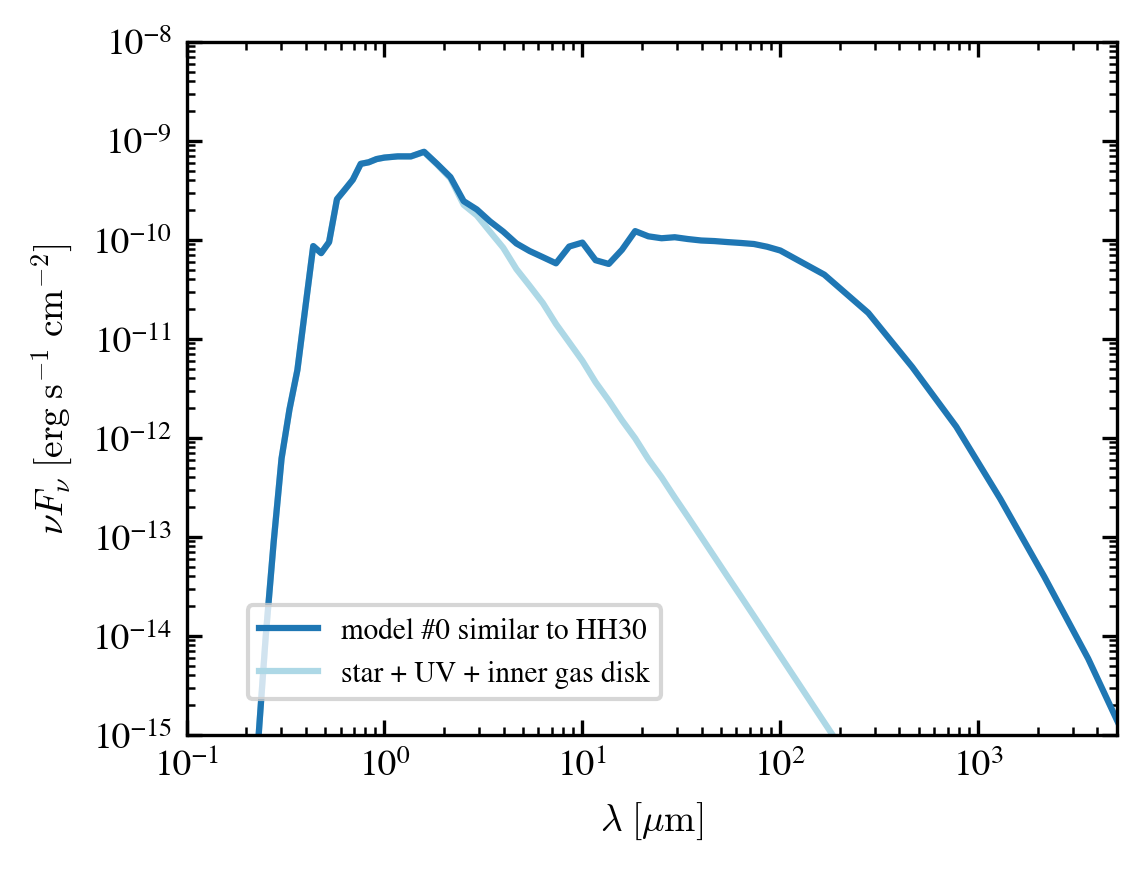

In [9]:
#
# GRID Define
#

fig0 = plt.figure(dpi=300, figsize = (4, 3))
ax_sed0 = fig0.add_subplot(1,1,1)

##########################
### Observational Data ###
##########################

# Photometry
# xxx

##################
### Model Data ###
##################

wave_mod_wuv = data_spec[:, 0]
fluxes_mod_wuv = data_spec[:, 1]
nu_mod_wuv = (wave_mod_wuv * u.um).to(u.Hz, equivalencies=u.spectral()).value
nufnu_mod_wuv = nu_mod_wuv * fluxes_mod_wuv

for ax_sed in [ax_sed0]:
    ax_sed.plot(wave_mod_wuv, nufnu_mod_wuv*(1/distance)**2, color='lightblue', label='star + UV + inner gas disk')

    # ax_sed.plot(wave_r22spec.to(u.um), nufnu_r22spec, color='red', label='new stellar spectra')

#######################
### RADMC-3D Result ###
#######################

model_name_list = [
    model_dirs[i_model_select],
]

sed_data_dir_list = [
    os.path.join(output_dir, model_dirs[i_model_select])
]

color_list = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6'] 

note_list = [
    'similar to HH30',
    ] * len(sed_data_dir_list)

for ii, sed_data_dir in enumerate(sed_data_dir_list):

    specname = os.path.join(sed_data_dir, "spectrum.out")

    s     = radmc3dPy.analyze.readSpectrum(specname)
    lam   = s[:,0]
    nu    = 1e4*radmc3dPy.natconst.cc/lam
    fnu   = s[:,1]
    #             nufnu_1pc = nu*fnu # the model seen from 1pc
    #             # scale according to its distance
    fnu_here = (fnu * (1/distance)**2)

    factor_mdiskd = 1.00 # 0.90
    
    print(note_list[ii])
    
    for ax_sed in [ax_sed0]:
    
        ax_sed.plot(lam, nu * fnu_here * factor_mdiskd, label = 'model #%i '%(ii)+'%s'%(note_list[ii]), color=color_list[ii], linestyle='-')
        
################################
### control factors for plot ###
################################

for ax_sed in [ax_sed0]:
    
    ax_sed.set_xscale('log')
    ax_sed.set_yscale('log')

"""whole region"""
ax_sed = ax_sed0
ax_sed.set_xlim(1e-1, 5e3)
ax_sed.set_ylim(1e8/1e23,1e15/1e23)

"""IR to mm"""
# ax_sed = ax_sed0
# ax_sed.set_xlim(1, 5e3)
# ax_sed.set_ylim(1e-13, 1e-9)

"""DSHARP wavelengths"""
# ax_sed = ax_sed0
# ax_sed.set_xlim(500, 4e3)
# ax_sed.set_ylim(1e-13, 5e-12)

"""mm and beyond"""
# ax_sed.set_xlim(500, 1e4)
# ax_sed.set_ylim(1e-15, 5e-12)

for ax_sed in [ax_sed0]:

    ax_sed.set_xlabel('$\lambda\; [\mu \mathrm{m}]$')
    ax_sed.set_ylabel('$\\nu F_\\nu \; [\mathrm{erg} \; \mathrm{s^{-1}} \; \mathrm{cm^{-2}}]$')

    handles, labels = ax_sed.get_legend_handles_labels()
    reorder = [int(len(handles)-1)] + [int(i) for i in range(len(handles)-1)]
    handles = [handles[i] for i in reorder]
    labels = [labels[i] for i in reorder]
    ax_sed.legend(handles, labels, loc = 'lower left', fontsize = 7, bbox_to_anchor=(0.05, 0.03))

# plt.savefig('./figures/Fig_SED_fitting.png', dpi = 300, bbox_inches='tight', pad_inches=0.1)

plt.show()